# Assignment 27/03/2025

## Imports

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import pytesseract

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import mahotas
from xgboost import XGBClassifier

# Section A

## Image loading

In [ ]:
fish_segment_image = cv2.imread('./images/1.jpg')
homography_players_image = cv2.imread('./images/2.png')
homography_field_image = cv2.imread('./images/3.png')
hand_segment_image = cv2.imread('./images/5.jpg')
plate_character_image = cv2.imread('./images/6.png')
face_detect_image = cv2.imread('./images/faces.jpg')

In [17]:
fish_segment = cv2.cvtColor(fish_segment_image, cv2.COLOR_BGR2RGB)
homography_players = cv2.cvtColor(homography_players_image, cv2.COLOR_BGR2RGB)
homography_field = cv2.cvtColor(homography_field_image, cv2.COLOR_BGR2RGB)
hand_segment = cv2.cvtColor(hand_segment_image, cv2.COLOR_BGR2RGB)
plate_character = cv2.cvtColor(plate_character_image, cv2.COLOR_BGR2RGB)
face_detect = cv2.cvtColor(face_detect_image, cv2.COLOR_BGR2RGB)

## 1. Fish Segmentation

In [12]:
image = fish_segment_image
image_rgb = fish_segment

In [13]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

Text(0.5, 0, 'Value')

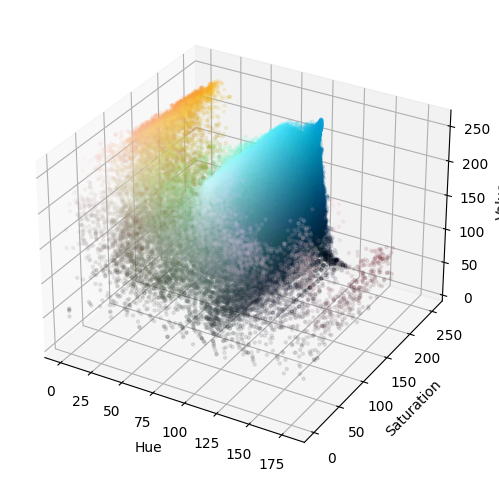

In [14]:
h, s, v = cv2.split(hsv)
pixel_colors = image_rgb.reshape((-1, 3)) / 255.0  # normalize to [0,1] for plotting


fig = plt.figure(figsize=(8,6))
axis = fig.add_subplot(1, 1, 1, projection="3d")
axis.scatter(h.flatten(), s.flatten(), v.flatten(), facecolors=pixel_colors, marker=".", alpha=0.1)
axis.set_xlabel("Hue")
axis.set_ylabel("Saturation")
axis.set_zlabel("Value")

In [4]:
lower_orange = np.array([5, 100, 100])
upper_orange = np.array([25, 255, 255])

mask = cv2.inRange(hsv, lower_orange, upper_orange)

result = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)

(-0.5, 409.5, 255.5, -0.5)

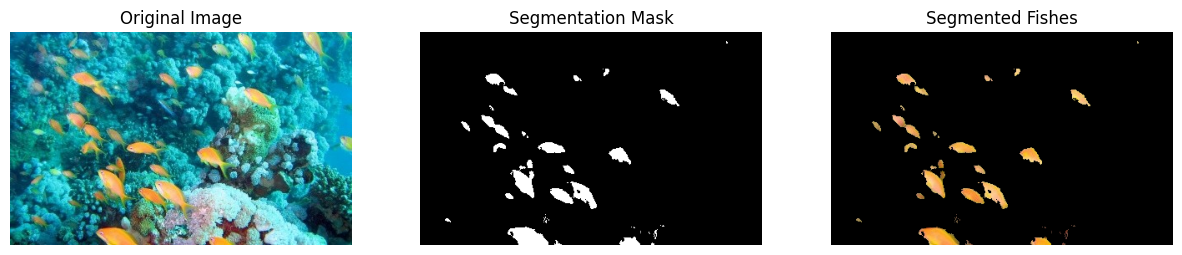

In [4]:
# Display the results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Segmentation Mask")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Segmented Fishes")
plt.imshow(result)
plt.axis('off')

## 2. Find Homography matrix and update the location of each player in the second image.

In [5]:
pts_src = np.array([
    [65, 158], 
    [219, 84],  
    [139, 76],  
    [105, 88],
    [130, 91],   
    [54, 120],   
    [25, 115], 
], dtype='float32') 

In [6]:
pts_dst = np.array([
    [73, 215], 
    [73, 55],  
    [0, 53],  
    [1, 99],
    [22, 98],   
    [23, 171],   
    [0, 171], 
], dtype='float32')

In [7]:
H, status = cv2.findHomography(pts_src, pts_dst)

In [8]:
players_img1 = np.array([
    [369, 127],
    [231, 91],
    [196, 110],
    [174, 112],
    [127, 126],
    [154, 106],
    [167, 91],
    [122, 109],
    [109, 112],
    [120, 102],
    [124, 96],
    [112, 98],
    [104, 106],
    [87, 101],
    [73, 102],
    [82, 94],
    [100, 96],
    [111, 91],
    [117, 89],
    [101, 89],
], dtype='float32')

players_img1_reshaped = players_img1.reshape(-1, 1, 2)

In [9]:
players_img2 = cv2.perspectiveTransform(players_img1_reshaped, H)
players_img2 = players_img2.reshape(-1, 2)

In [10]:
output = homography_field.copy()
for (x, y) in players_img2:
    cv2.circle(output, (int(x), int(y)), 5, (255, 0, 0), -1)

(-0.5, 480.5, 269.5, -0.5)

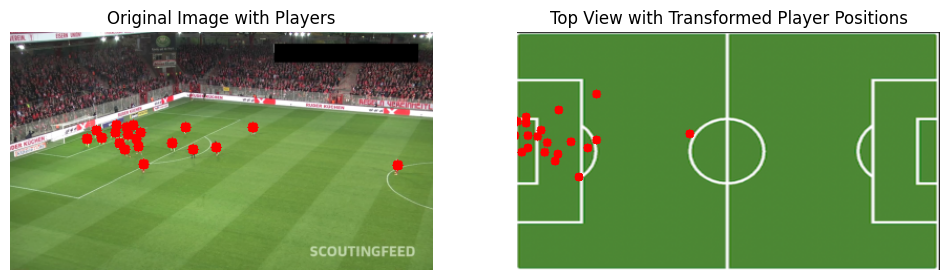

In [11]:
# Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image with Players")
for (x, y) in players_img1:
    cv2.circle(homography_players, (int(x), int(y)), 5, (255, 0, 0), -1)
plt.imshow(homography_players)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Top View with Transformed Player Positions")
plt.imshow(output)
plt.axis('off')

## 3. Detect outlier using RANSAC algorithm from the given data

Outliers detected: [[ 0  0]
 [ 1  0]
 [ 2  0]
 [ 3  0]
 [10 10]]


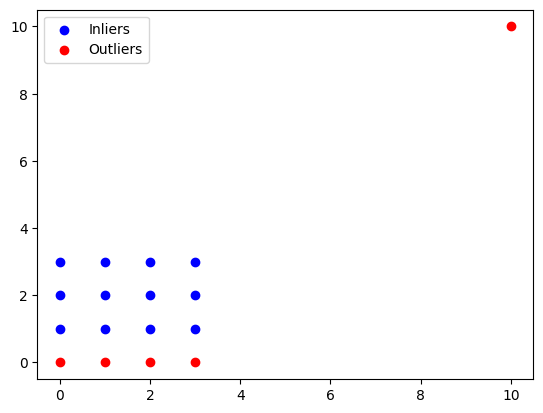

In [8]:
# REFERENCING: https://pyihub.org/ransac/
from sklearn.linear_model import RANSACRegressor
data = np.array([
    (2, 2), (1, 1), (1, 2), (2, 1), (3, 2), (2, 3), (3, 3),
    (1, 3), (3, 1), (0, 0), (0, 1), (1, 0), (0, 2), (2, 0),
    (3, 0), (0, 3), (10, 10)
])

X = data[:, 0].reshape(-1, 1)
y = data[:, 1]

ransac = RANSACRegressor()
ransac.fit(X, y)

inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

outliers = data[outlier_mask]
print("Outliers detected:", outliers)

plt.scatter(X[inlier_mask], y[inlier_mask], color='blue', label='Inliers')
plt.scatter(X[outlier_mask], y[outlier_mask], color='red', label='Outliers')
plt.legend()
plt.show()

## 4. Apply face detection to detect faces in an image. Show that it failed to detect some faces. Then improve the detection model and show that the model can now detect all the faces.

In [18]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [19]:
faces_default = face_cascade.detectMultiScale(face_detect)

In [20]:
image_default = face_detect.copy()
for (x, y, w, h) in faces_default:
    cv2.rectangle(image_default, (x, y), (x + w, y + h), (0, 255, 0), 2)

In [21]:
faces_improved = face_cascade.detectMultiScale(
    face_detect,
    scaleFactor=1.05,      # Finer scale for detecting smaller faces
    minNeighbors=3,        # More sensitive
    minSize=(30, 30)
)

In [22]:
image_improved = face_detect.copy()
for (x, y, w, h) in faces_improved:
    cv2.rectangle(image_improved, (x, y), (x + w, y + h), (0, 255, 0), 2)

(-0.5, 999.5, 499.5, -0.5)

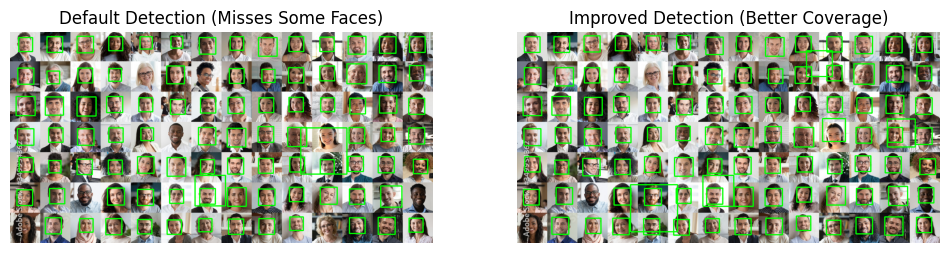

In [23]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Default Detection (Misses Some Faces)")
plt.imshow(image_default)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Improved Detection (Better Coverage)")
plt.imshow(image_improved)
plt.axis('off')

## 5. Apply color-based segmentation to segment the hand

In [18]:
# REFERENCING: https://realpython.com/python-opencv-color-spaces/
hsv_hand_segment = cv2.cvtColor(hand_segment, cv2.COLOR_RGB2HSV)

Text(0.5, 0, 'Value')

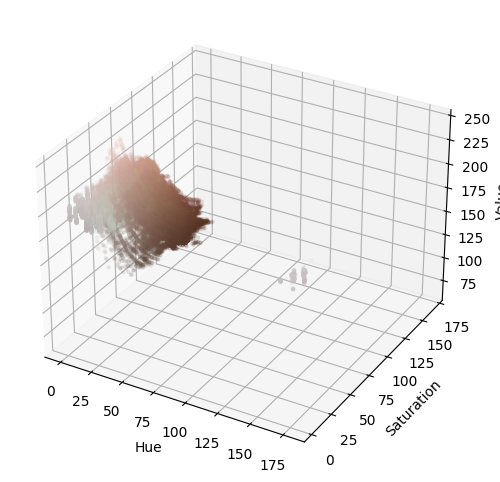

In [19]:
h, s, v = cv2.split(hsv_hand_segment)
pixel_colors = hand_segment.reshape((-1, 3)) / 255.0  # normalize to [0,1] for plotting


fig = plt.figure(figsize=(8,6))
axis = fig.add_subplot(1, 1, 1, projection="3d")
axis.scatter(h.flatten(), s.flatten(), v.flatten(), facecolors=pixel_colors, marker=".", alpha=0.1)
axis.set_xlabel("Hue")
axis.set_ylabel("Saturation")
axis.set_zlabel("Value")

In [20]:
lower_skin = np.array([0, 40, 60], dtype=np.uint8)
upper_skin = np.array([50, 255, 255], dtype=np.uint8)

In [21]:
mask = cv2.inRange(hsv_hand_segment, lower_skin, upper_skin)
result = cv2.bitwise_and(hand_segment, hand_segment, mask=mask)

(-0.5, 325.5, 435.5, -0.5)

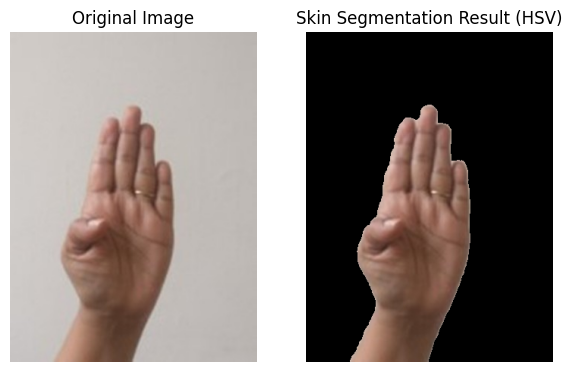

In [22]:
plt.figure(figsize=(7, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(hand_segment)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Skin Segmentation Result (HSV)")
plt.imshow(result)
plt.axis('off')

## 6. Enhance for License Plate character detection, classify each character.

In [23]:
grayscale_auto_thresh = cv2.cvtColor(plate_character, cv2.COLOR_RGB2GRAY)

In [24]:
# FROM DOCUMENTATION: https://docs.opencv.org/3.4/d7/d4d/tutorial_py_thresholding.html
blur = cv2.GaussianBlur(grayscale_auto_thresh,(5,5),0)
# find normalized_histogram, and its cumulative distribution function
hist = cv2.calcHist([blur],[0],None,[256],[0,256])
hist_norm = hist.ravel()/hist.sum()
Q = hist_norm.cumsum()
bins = np.arange(256)
fn_min = np.inf
thresh = -1
for i in range(1,256):
    p1,p2 = np.hsplit(hist_norm,[i]) # probabilities
    q1,q2 = Q[i],Q[255]-Q[i] # cum sum of classes
    if q1 < 1.e-6 or q2 < 1.e-6:
        continue
    b1,b2 = np.hsplit(bins,[i]) # weights
    # finding means and variances
    m1,m2 = np.sum(p1*b1)/q1, np.sum(p2*b2)/q2
    v1,v2 = np.sum(((b1-m1)**2)*p1)/q1,np.sum(((b2-m2)**2)*p2)/q2
    # calculates the minimization function
    fn = v1*q1 + v2*q2
    if fn < fn_min:
        fn_min = fn
        thresh = i
# find otsu's threshold value with OpenCV function
ret, otsu = cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
print( "{} {}".format(thresh,ret) )

67 67.0


Text(0.5, 1.0, 'Optimal Thresholding (T = 67.00)')

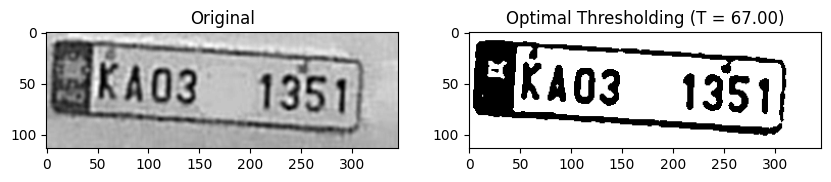

In [25]:
plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(grayscale_auto_thresh, cmap='gray')
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(otsu, cmap='gray')
plt.title(f"Optimal Thresholding (T = {thresh:.2f})")

In [26]:
# REFERENCING: 
# 1. https://www.geeksforgeeks.org/text-detection-and-extraction-using-opencv-and-ocr/
# 2. https://docs.opencv.org/4.11.0/d4/d73/tutorial_py_contours_begin.html
contours, hierarchy = cv2.findContours(otsu, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

In [27]:
im2 = otsu.copy()

In [28]:
pytesseract.pytesseract.tesseract_cmd = "C:/Program Files/Tesseract-OCR/tesseract.exe"

In [29]:
identified = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    
    # Drawing a rectangle on copied image
    rect = cv2.rectangle(im2, (x, y), (x + w, y + h), (0, 255, 0), 2)
    
    # Cropping the text block for giving input to OCR
    cropped = im2[y:y + h, x:x + w]
    
    # Apply OCR on the cropped image
    text = pytesseract.image_to_string(cropped)
    identified.append(text)

In [30]:
for x in identified:
    if len(x) > 2:
        print(x)

KA03 1351


Ki



# Section B

## 12.	Crops classification 

In [ ]:
test = cv2.imread('./datasets/Agricultural-crops/almond/image (1).jpg')
test = cv2.resize(test, (128, 128))  # Standard size
means, stds = cv2.meanStdDev(test)
means.flatten()

array([ 86.7947998 , 101.78186035,  97.29888916])

In [2]:
def get_color_histograms(image):
    hist_features = []
    for i in range(3):  # BGR channels
        hist = cv2.calcHist([image], [i], None, [32], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        hist_features.extend(hist)
    return hist_features

In [3]:
# REFERENCING: https://mahotas.readthedocs.io/en/latest/classification.html
def extract_features(image_path):
    # image = cv2.imread(image_path)
    image = cv2.resize(image_path, (128, 128))  # Standard size
    features = []

    # rgb features
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    means, stds = cv2.meanStdDev(rgb)
    features.extend(means.flatten())
    features.extend(stds.flatten())

    # hsv features
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    means, stds = cv2.meanStdDev(hsv)
    features.extend(means.flatten())
    features.extend(stds.flatten())

    # haralick texture features
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    haralick = mahotas.features.haralick(gray).mean(0)
    features.extend(haralick)
    
    # color Histogram
    features.extend(get_color_histograms(image))

    
    return features

In [ ]:
X = []
y = []
for label in os.listdir("./datasets/Agricultural-crops/"):
    class_dir = os.path.join("./datasets/Agricultural-crops", label)
    for img_file in os.listdir(class_dir):
        path = os.path.join(class_dir, img_file)
        features = extract_features(path)
        X.append(features)
        y.append(label)
X = np.array(X)
y = np.array(y)
len(y)

829

In [55]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [38]:
# clf = RandomForestClassifier(n_estimators=100, random_state=42)
# Initialize the XGBClassifier
clf = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss')

# Fit the model
clf.fit(X_train, y_train)

C:\Users\homea\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:59:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [39]:
y_pred = clf.predict(X_test)

In [40]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.29518072289156627

Classification Report:
                      precision    recall  f1-score   support

             Cherry       0.50      0.44      0.47         9
       Coffee-plant       0.00      0.00      0.00         7
           Cucumber       0.20      0.14      0.17         7
   Fox_nut(Makhana)       1.00      0.25      0.40         4
              Lemon       0.33      0.25      0.29         4
         Olive-tree       0.11      0.33      0.17         3
Pearl_millet(bajra)       0.50      0.33      0.40        12
      Tobacco-plant       0.33      0.40      0.36         5
             almond       0.25      0.25      0.25         4
             banana       0.00      0.00      0.00         7
           cardamom       0.18      0.33      0.24         6
             chilli       0.29      0.50      0.36         4
              clove       0.00      0.00      0.00         3
            coconut       0.00      0.00      0.00         2
             cotton       0.1

## 14. Cat dog classification 

In [ ]:
X = []
y = []
for label in os.listdir("./datasets/Cats-dogs/"):
    class_dir = os.path.join("./datasets/Cats-dogs", label)
    for img_file in os.listdir(class_dir):
        path = os.path.join(class_dir, img_file)
        features = extract_features(path)
        X.append(features)
        y.append(label)
X = np.array(X)
y = np.array(y)
len(y)

697

In [42]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [44]:
# clf = RandomForestClassifier(n_estimators=100, random_state=42)
# Initialize the XGBClassifier
clf = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss')

# Fit the model
clf.fit(X_train, y_train)

C:\Users\homea\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:59:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [45]:
y_pred = clf.predict(X_test)

In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.6142857142857143

Classification Report:
               precision    recall  f1-score   support

        cats       0.68      0.58      0.62        78
        dogs       0.55      0.66      0.60        62

    accuracy                           0.61       140
   macro avg       0.62      0.62      0.61       140
weighted avg       0.63      0.61      0.62       140

